Compiling model...
'compile' took 0.000159 s

Training model...

Step      Train loss              Test loss               Test metric
0         [3.28e+02, 8.73e-01]    [3.28e+02, 8.72e-01]    []  
1000      [2.16e+00, 5.97e-01]    [2.07e+00, 5.88e-01]    []  
2000      [9.04e-01, 4.30e-01]    [8.57e-01, 4.19e-01]    []  
3000      [3.85e-01, 3.28e-01]    [3.68e-01, 3.20e-01]    []  
4000      [2.00e-01, 3.26e-01]    [1.93e-01, 3.19e-01]    []  
5000      [1.31e-01, 1.93e-01]    [1.28e-01, 1.88e-01]    []  
6000      [8.63e-02, 4.31e-01]    [8.51e-02, 4.27e-01]    []  
7000      [7.88e-02, 1.36e-01]    [7.83e-02, 1.33e-01]    []  
8000      [6.26e-02, 1.05e-01]    [6.24e-02, 1.03e-01]    []  
9000      [4.86e-02, 8.28e-02]    [4.85e-02, 8.14e-02]    []  
10000     [4.31e-02, 6.99e-02]    [4.31e-02, 6.91e-02]    []  
11000     [3.54e-02, 5.97e-02]    [3.53e-02, 5.92e-02]    []  
12000     [4.64e-02, 5.02e-02]    [4.64e-02, 4.99e-02]    []  
13000     [2.86e-02, 3.34e-02]    [2.85e-02, 3

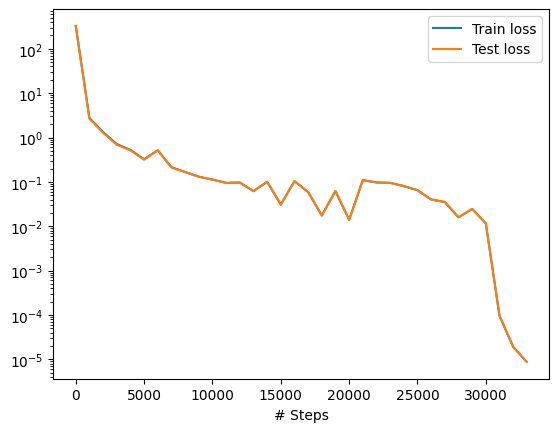

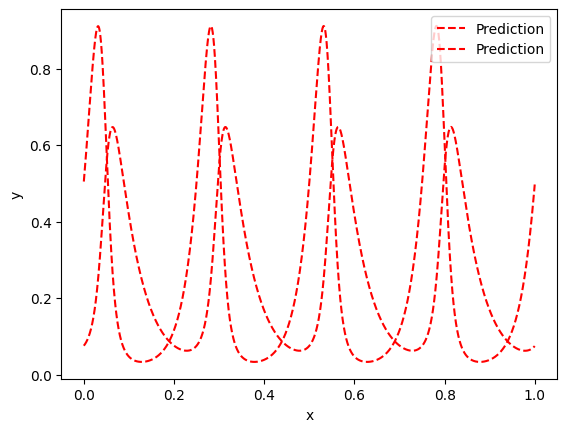

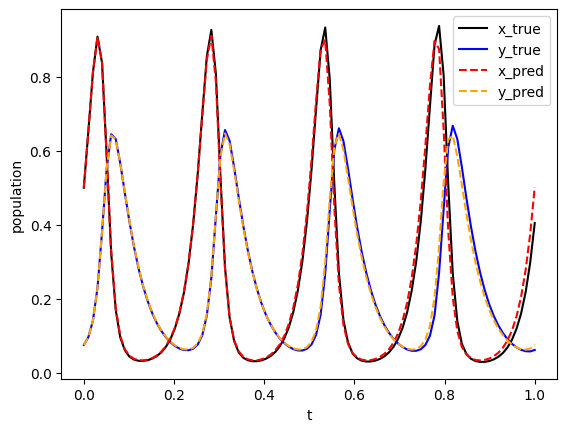

In [11]:
import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate
import torch

ub = 200   #Upper bound 
rb = 20    # Lower bound

def func(t, r):
    x, y = r
    dx_t = 1 / ub * rb * (2.0 * ub * x - 0.04 * ub * x * ub * y)
    dy_t = 1 / ub * rb * (0.02 * ub * x * ub * y - 1.06 * ub * y)
    return dx_t, dy_t

def gen_truedata():
    t = np.linspace(0, 1, 100)

    sol = integrate.solve_ivp(func, (0, 10), (100 / ub, 15 / ub), t_eval=t)
    x_true, y_true = sol.y
    x_true = x_true.reshape(100, 1)
    y_true = y_true.reshape(100, 1)

    return x_true, y_true


def ode_system(x, y):
    r = y[:, 0:1]
    p = y[:, 1:2]
    dr_t = dde.grad.jacobian(y, x, i=0)
    dp_t = dde.grad.jacobian(y, x, i=1)
    return [
        dr_t - 1 / ub * rb * (2.0 * ub * r - 0.04 * ub * r * ub * p),
        dp_t - 1 / ub * rb * (0.02 * r * ub * p *ub - 1.06 * p * ub),
    ]

geom = dde.geometry.TimeDomain(0, 1.0)
data = dde.data.PDE(geom, ode_system, [], 3000, 2, num_test = 3000)


layer_size = [7] + [64] * 6 + [2]
activation = "tanh"
initializer = "Glorot normal"
net = dde.nn.FNN(layer_size, activation, initializer)



def input_transform(t):
    return torch.cat(
        [    
            t,
            torch.sin(t),
            torch.sin(2 * t),
            torch.sin(3 * t),
            torch.sin(4 * t),
            torch.sin(5 * t),
            torch.sin(6 * t),
        ],
        dim=1,
    )
    

def output_transform(t, y):
    y1 = y[:, 0:1]
    y2 = y[:, 1:2]

    return torch.cat([y1 * torch.tanh(t) + 100 / ub, y2 * torch.tanh(t) + 15 / ub], dim=1)

net.apply_feature_transform(input_transform)
net.apply_output_transform(output_transform)

model = dde.Model(data, net)
model.compile("adam", lr=0.001)
losshistory, train_state = model.train(iterations=30000)

model.compile("L-BFGS")
losshistory, train_state = model.train()
dde.saveplot(losshistory, train_state, issave=False, isplot=True)
plt.xlabel("t")
plt.ylabel("population")

t = np.linspace(0, 1, 100)
x_true, y_true = gen_truedata()
plt.plot(t, x_true, color="black", label="x_true")
plt.plot(t, y_true, color="blue", label="y_true")

t = t.reshape(100, 1)
sol_pred = model.predict(t)
x_pred = sol_pred[:, 0:1]
y_pred = sol_pred[:, 1:2]

plt.plot(t, x_pred, color="red", linestyle="dashed", label="x_pred")
plt.plot(t, y_pred, color="orange", linestyle="dashed", label="y_pred")
plt.legend()
plt.show()